# MotoGP 2024 - Data Visualization

### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import storage
from io import StringIO

Matplotlib is building the font cache; this may take a moment.


#### Set Style for Plots

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']= (12, 6)
plt.rcParams['font.size']= 10

### Load Data from Cloud Storage

#### Configuration

In [4]:
PROJECT_ID= 'motogp-racing-analytics'
BUCKET_NAME= 'motogp-racing-data-2024'
FILE_NAME= 'motogp_2024_results.csv'

#### Connect to Cloud Storage

In [5]:
storage_client= storage.Client(project= PROJECT_ID)
bucket= storage_client.bucket(BUCKET_NAME)
blob= bucket.blob(FILE_NAME)

#### Download and Load Data

In [7]:
csv_data= blob.download_as_text()
df= pd.read_csv(StringIO(csv_data))

print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Rows: 23
Columns: ['Round', 'Date', 'Grand Prix', 'Circuit', 'Winning rider', 'Pole position', 'Fastest lap']


,Round,Date,Grand Prix,Circuit,Winning rider,Pole position,Fastest lap
0,1,10 March,Qatar Airways Grand Prix of Qatar,"Lusail International Circuit,Lusail",Francesco Bagnaia,Jorge Martín,Pedro Acosta
1,2,24 March,Grande Prémio Tissot de Portugal,"Algarve International Circuit,Portimão",Jorge Martín,Enea Bastianini,Enea Bastianini
2,3,14 April,Red Bull Grand Prix of the Americas,"Circuit of the Americas,Austin",Maverick Viñales,Maverick Viñales,Maverick Viñales
3,4,28 April,"Gran Premio Estrella Galicia 0,0 de España","Circuito de Jerez – Ángel Nieto,Jerez de la Fr...",Francesco Bagnaia,Marc Márquez,Francesco Bagnaia
4,5,12 May,Michelin Grand Prix de France,"Bugatti Circuit,Le Mans",Jorge Martín,Jorge Martín,Enea Bastianini


### Data Preparation

In [10]:
print("Winning Rider Distribution:")
print(df['Winning rider'].value_counts())
print()
print("Pole Position Distribution:")
print(df['Pole position'].value_counts())
print()
print("Fastest Lap Distribution:")
print(df['Fastest lap'].value_counts())

Winning Rider Distribution:
Winning rider
Francesco Bagnaia    11
Jorge Martín          3
Marc Márquez          3
Maverick Viñales      1
Enea Bastianini       1
Name: count, dtype: int64

Pole Position Distribution:
Pole position
Jorge Martín         7
Francesco Bagnaia    5
Marc Márquez         2
Aleix Espargaró      2
Enea Bastianini      1
Maverick Viñales     1
Pedro Acosta         1
Name: count, dtype: int64

Fastest Lap Distribution:
Fastest lap
Francesco Bagnaia        5
Marc Márquez             4
Enea Bastianini          3
Pedro Acosta             2
Jorge Martín             2
Maverick Viñales         1
Aleix Espargaró          1
Fabio Di Giannantonio    1
Name: count, dtype: int64


### Viz_01 - Bar Chart - Wins by Rider

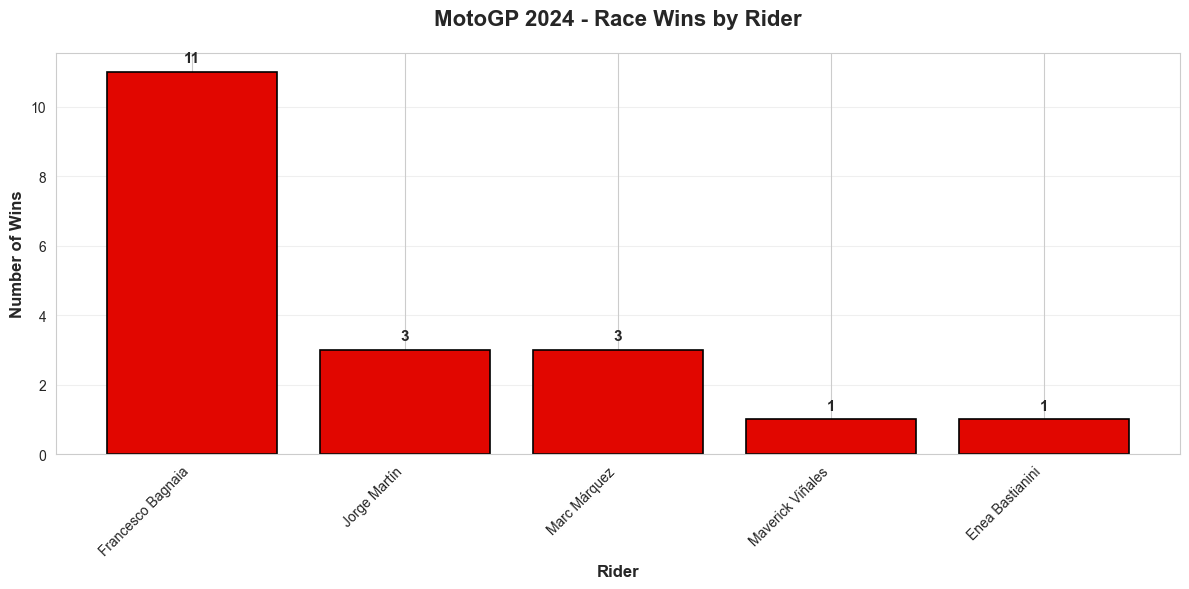

In [11]:
wins= df['Winning rider'].value_counts().head(10)

plt.figure(figsize= (12, 6))
bars= plt.bar(range(len(wins)), wins.values, color= '#e10600', edgecolor= 'black', linewidth= 1.2)

plt.xlabel('Rider', fontsize= 12, fontweight= 'bold')
plt.ylabel('Number of Wins', fontsize= 12, fontweight= 'bold')
plt.title('MotoGP 2024 - Race Wins by Rider', fontsize= 16, fontweight= 'bold', pad= 20)
plt.xticks(range(len(wins)), wins.index, rotation= 45, ha= 'right')
plt.grid(axis= 'y', alpha= 0.3)

for i, (bar, value) in enumerate(zip(bars, wins.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             str(value), ha= 'center', va= 'bottom', fontweight= 'bold', fontsize= 11)

plt.tight_layout()
plt.savefig('viz_01_wins_by_rider.png', dpi= 300, bbox_inches= 'tight')
plt.show()

### Viz_2 - Horizontal Bar - Pole Positions

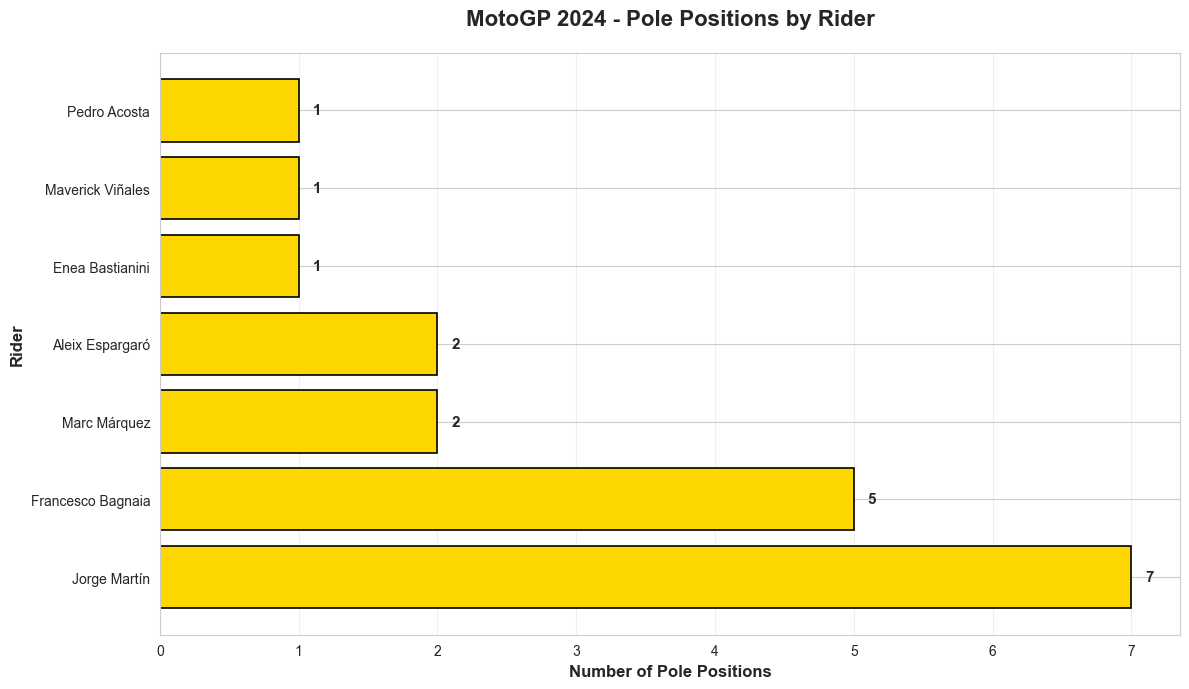

In [12]:
poles= df['Pole position'].value_counts().head(10)

plt.figure(figsize= (12, 7))
bars= plt.barh(range(len(poles)), poles.values, color= '#ffd700', edgecolor= 'black', linewidth= 1.2)

plt.xlabel('Number of Pole Positions', fontsize= 12, fontweight= 'bold')
plt.ylabel('Rider', fontsize= 12, fontweight= 'bold')
plt.title('MotoGP 2024 - Pole Positions by Rider', fontsize= 16, fontweight= 'bold', pad= 20)
plt.yticks(range(len(poles)), poles.index)
plt.grid(axis= 'x', alpha= 0.3)

for i, (bar, value) in enumerate(zip(bars, poles.values)):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
             str(value), ha= 'left', va= 'center', fontweight= 'bold', fontsize= 11)

plt.tight_layout()
plt.savefig('viz_02_pole_positions.png', dpi= 300, bbox_inches= 'tight')
plt.show()

### Viz_03 - Pie Chart - Win Distribution

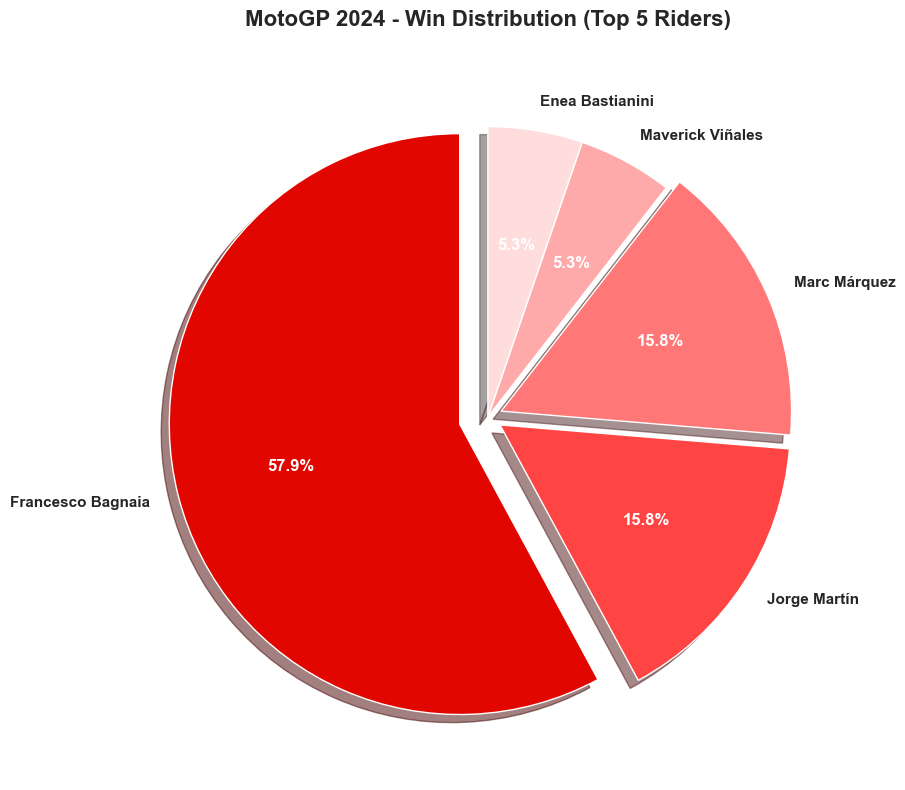

In [13]:
wins_top5= df['Winning rider'].value_counts().head(5)

plt.figure(figsize= (10, 8))
colors= ['#e10600', '#ff4444', '#ff7777', '#ffaaaa', '#ffdddd']
explode= (0.1, 0.05, 0.05, 0, 0)

wedges, texts, autotexts= plt.pie(wins_top5.values, 
                                  labels= wins_top5.index,
                                  autopct= '%1.1f%%',
                                  startangle= 90,
                                  colors= colors,
                                  explode= explode,
                                  shadow= True,
                                  textprops= {'fontsize': 11, 'fontweight': 'bold'})

plt.title('MotoGP 2024 - Win Distribution (Top 5 Riders)', fontsize= 16, fontweight= 'bold', pad= 20)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

plt.tight_layout()
plt.savefig('viz_03_win_distribution.png', dpi= 300, bbox_inches= 'tight')
plt.show()

### Viz_04 - Grouped Bar - Performance Comparison

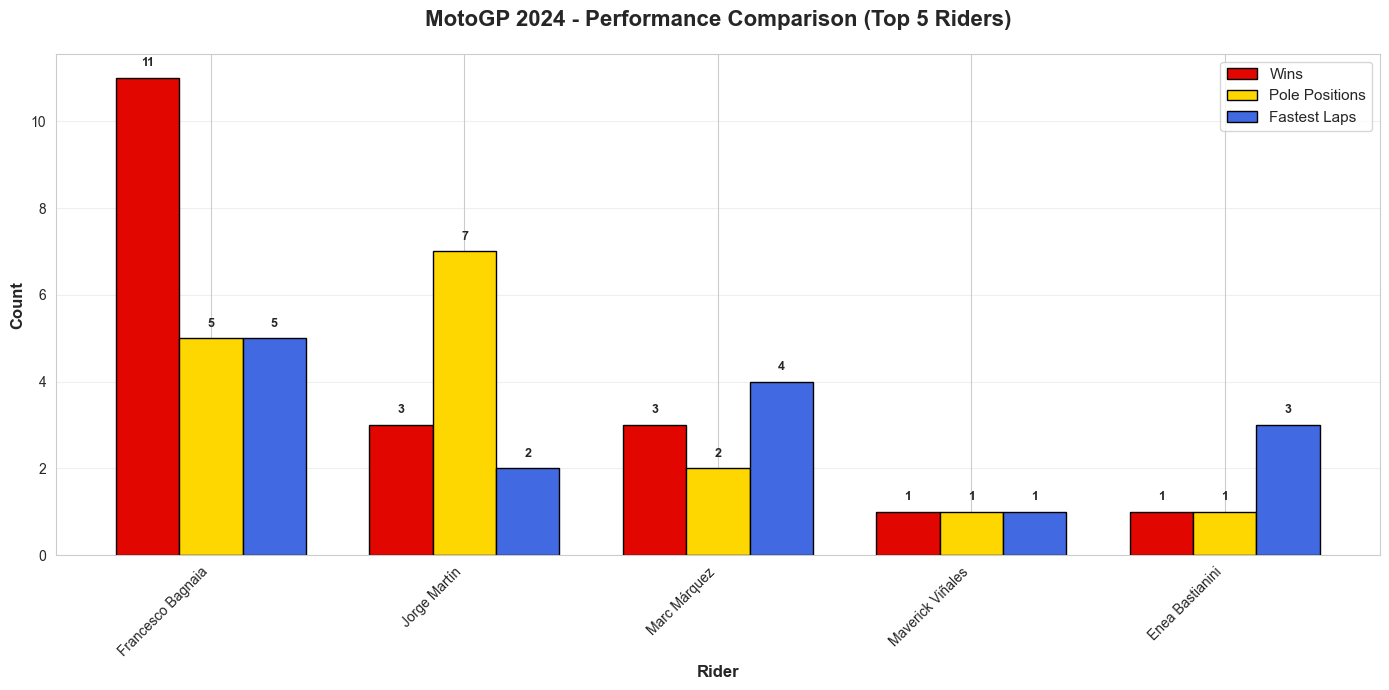

In [14]:
# Top 5 riders
top_riders= df['Winning rider'].value_counts().head(5).index

data_comparison= []
for rider in top_riders:
    wins_count= len(df[df['Winning rider']== rider])
    poles_count= len(df[df['Pole position']== rider])
    fastest_count= len(df[df['Fastest lap']== rider])
    data_comparison.append({'Rider': rider,
                            'Wins': wins_count,
                            'Poles': poles_count,
                            'Fastest Laps': fastest_count
                            })

df_comparison= pd.DataFrame(data_comparison)

x= range(len(df_comparison))
width= 0.25

fig, ax= plt.subplots(figsize= (14, 7))

bars1= ax.bar([i - width for i in x], df_comparison['Wins'], width, 
               label= 'Wins', color= '#e10600', edgecolor= 'black', linewidth= 1)
bars2= ax.bar([i for i in x], df_comparison['Poles'], width, 
               label= 'Pole Positions', color= '#ffd700', edgecolor= 'black', linewidth= 1)
bars3= ax.bar([i + width for i in x], df_comparison['Fastest Laps'], width, 
               label= 'Fastest Laps', color= '#4169e1', edgecolor= 'black', linewidth= 1)

ax.set_xlabel('Rider', fontsize= 12, fontweight= 'bold')
ax.set_ylabel('Count', fontsize= 12, fontweight= 'bold')
ax.set_title('MotoGP 2024 - Performance Comparison (Top 5 Riders)', 
             fontsize= 16, fontweight= 'bold', pad= 20)
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Rider'], rotation= 45, ha= 'right')
ax.legend(fontsize= 11)
ax.grid(axis= 'y', alpha= 0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height= bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                   f'{int(height)}', ha= 'center', va= 'bottom', fontweight= 'bold', fontsize= 9)

plt.tight_layout()
plt.savefig('viz_04_performance_comparison.png', dpi= 300, bbox_inches= 'tight')
plt.show()

 ### Viz_05 - Cumulative Wins Race by Race

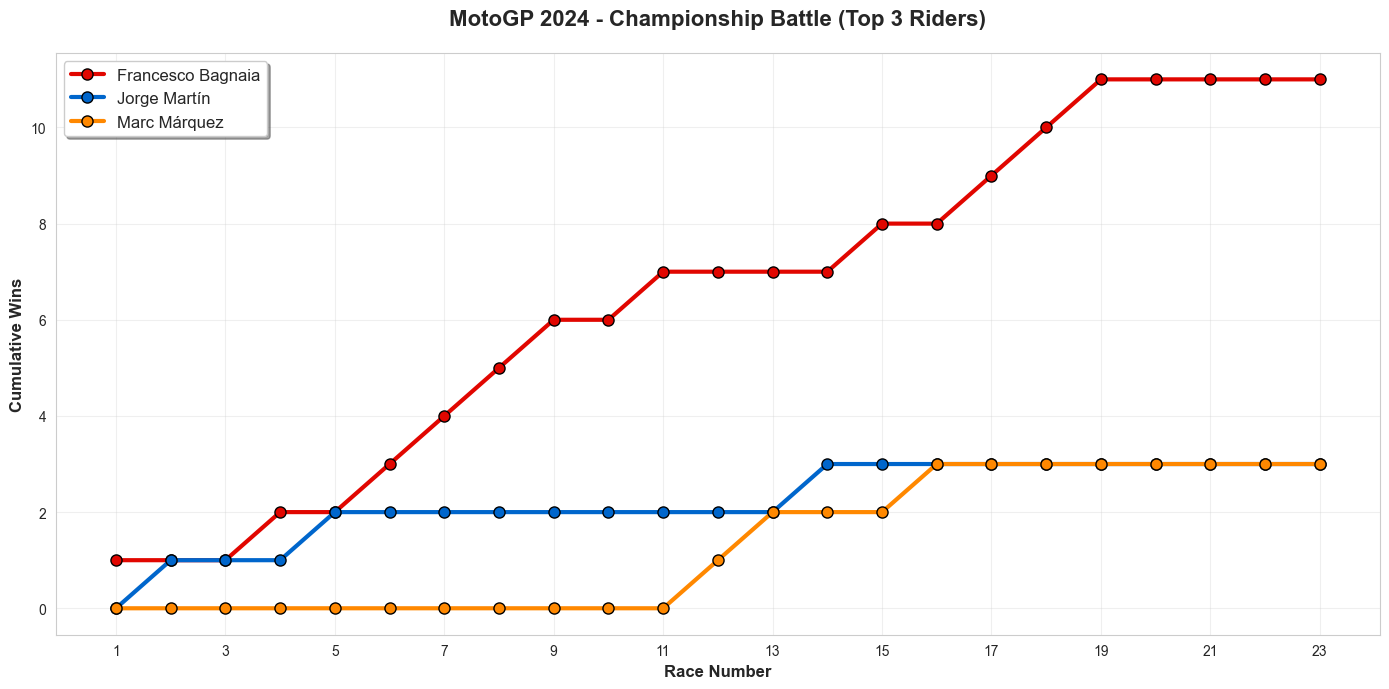

In [21]:
# Get top 3 riders by total wins
top_3_riders= df['Winning rider'].value_counts().head(3).index.tolist()

cumulative_wins= {rider: [] for rider in top_3_riders}

for race_num in range(1, len(df) + 1):
    races_so_far= df.head(race_num)
    for rider in top_3_riders:
        wins_count= len(races_so_far[races_so_far['Winning rider']== rider])
        cumulative_wins[rider].append(wins_count)

plt.figure(figsize= (14, 7))
colors_line= ['#e10600', '#0066cc', '#ff8800']

for rider, color in zip(top_3_riders, colors_line):
    plt.plot(range(1, len(df) + 1), cumulative_wins[rider], marker= 'o', linewidth= 3, markersize= 8, label= rider, color= color, markeredgecolor= 'black', markeredgewidth= 1)

plt.xlabel('Race Number', fontsize= 12, fontweight= 'bold')
plt.ylabel('Cumulative Wins', fontsize= 12, fontweight= 'bold')
plt.title('MotoGP 2024 - Championship Battle (Top 3 Riders)', fontsize= 16, fontweight= 'bold', pad= 20)
plt.legend(fontsize= 12, loc= 'upper left', frameon= True, shadow= True)
plt.grid(True, alpha= 0.3)
plt.xticks(range(1, len(df) + 1, 2))

plt.tight_layout()
plt.savefig('viz_05_championship_battle.png', dpi= 300, bbox_inches= 'tight')
plt.show()

In [37]:
print(f"Champion: {df['Winning rider'][0]} with {max(df['Winning rider'].value_counts())} wins!")
print(f"Total races: {len(df)}")
print(f"Different winners: {df['Winning rider'].nunique()}")

Champion: Francesco Bagnaia with 11 wins!
Total races: 23
Different winners: 5
